# Segmentasi Nasabah Kartu Kredit Berdasarkan Pola Penggunaan

Credit Card Dataset for Clustering, diambil dari kaggle.com dengan link sebagai berikut:

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ccdata' dataset.
Path to dataset files: /kaggle/input/ccdata


## 1. Business Understanding

### 1.1 Latar Belakang

Setiap nasabah kartu kredit memiliki pola penggunaan yang berbeda-beda, mulai dari besar saldo, frekuensi dan nilai transaksi, proporsi pembelanjaan tunai (cash advance) maupun cicilan, hingga perilaku pembayaran tagihan. Tanpa pemetaan yang sistematis, bank cenderung memperlakukan seluruh nasabah secara seragam dalam hal pemasaran, penawaran limit, maupun manajemen risiko, padahal karakteristik perilaku tiap nasabah sangat beragam. Pengelompokan berbasis data diperlukan agar bank dapat memahami keragaman perilaku ini secara terukur dan objektif.

### 1.2 Alasan Pemilihan Dataset

Dataset Credit Card Customer Segmentation dipilih karena memuat rekaman perilaku finansial nasabah kartu kredit secara menyeluruh selama periode 6 bulan, mencakup saldo (BALANCE), pola pembelian (PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES), penggunaan cash advance, limit kredit (CREDIT_LIMIT), riwayat pembayaran (PAYMENTS, MINIMUM_PAYMENTS), hingga lama keanggotaan (TENURE). Kombinasi 17 variabel numerik ini memungkinkan analisis segmentasi perilaku nasabah dilakukan secara komprehensif dalam satu set data.

### 1.3 Alasan Kelayakan Dataset untuk Clustering

Dataset ini sangat layak digunakan untuk algoritma clustering karena hampir seluruh variabelnya berupa data numerik kontinu tanpa label kategori target yang sudah ditentukan sebelumnya. Hubungan antar-variabel seperti saldo, frekuensi transaksi, dan perilaku pembayaran secara alami membentuk pola kelompok yang berbeda antar nasabah, sehingga cocok diolah menggunakan pendekatan unsupervised learning untuk menemukan segmen nasabah secara otomatis berdasarkan kemiripan pola perilaku.

### 1.4 Pertanyaan Bisnis

* Bagaimana mengelompokkan nasabah kartu kredit ke dalam beberapa segmen berdasarkan pola penggunaan kartu kredit mereka menggunakan teknik clustering?
* Secara spesifik, karakteristik apa yang membedakan segmen nasabah bernilai tinggi (high-value), nasabah dengan ketergantungan cash advance tinggi, dan nasabah pasif/dormant?

## 2. Data Understanding

### 2.1 Load Dataset & Inspeksi Struktur Data
Tahap awal Data Understanding bertujuan untuk memuat dataset dan memeriksa struktur umum data mentah, meliputi jumlah baris, jumlah kolom, tipe data masing-masing variabel, serta tampilan sampel awal sebelum melakukan pemfilteran atau seleksi fitur.

In [2]:
# Import library yang dibutuhkan
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# Cari file CSV di dalam folder hasil download kagglehub
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Menampilkan 5 baris pertama data mentah
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Menampilkan dimensi dataset
print("Dimensi dataset:", df.shape)

Dimensi dataset: (8950, 18)


In [5]:
# Ringkasan informasi tipe data dan jumlah non-null
print("\nInformasi Tipe Data:")
df.info()


Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null

### 2.2 Pemeriksaan Missing Values dan Data Duplikat
Pada tahap ini, dilakukan identifikasi terhadap nilai yang hilang (*missing values*) di seluruh fitur serta pengecekan keberadaan baris data yang duplikat untuk memastikan kualitas dan integritas dataset.

In [6]:
# Cek jumlah missing value per kolom
print("Jumlah Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Jumlah Missing Values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


In [7]:
# Cek jumlah data duplikat
print("\nJumlah Data Duplikat:", df.duplicated().sum())


Jumlah Data Duplikat: 0


### 2.3 Ringkasan Statistik Deskriptif
Melihat gambaran umum statistik data numerik untuk mengetahui sebaran nilai rata-rata, nilai minimum, hingga nilai maksimum.

In [9]:
# Ringkasan statistik deskriptif kolom numerik
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### 2.4 Visualisasi Dataset

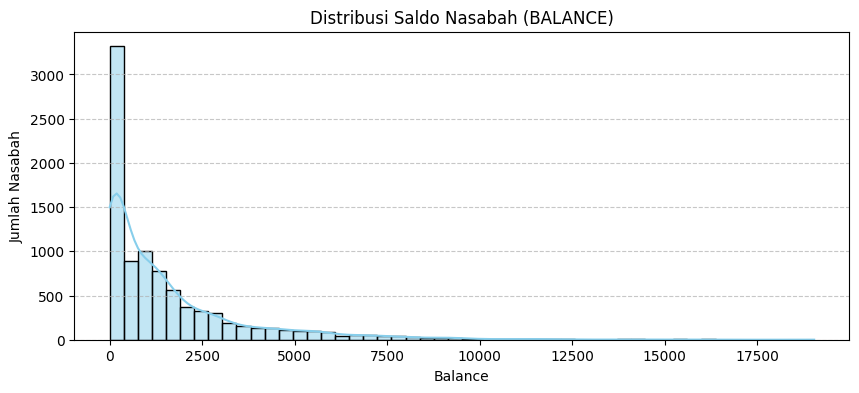

In [10]:
# 1. Distribusi saldo nasabah (BALANCE)
plt.figure(figsize=(10, 4))
sns.histplot(df['BALANCE'], bins=50, kde=True, color='skyblue')
plt.title('Distribusi Saldo Nasabah (BALANCE)')
plt.xlabel('Balance')
plt.ylabel('Jumlah Nasabah')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

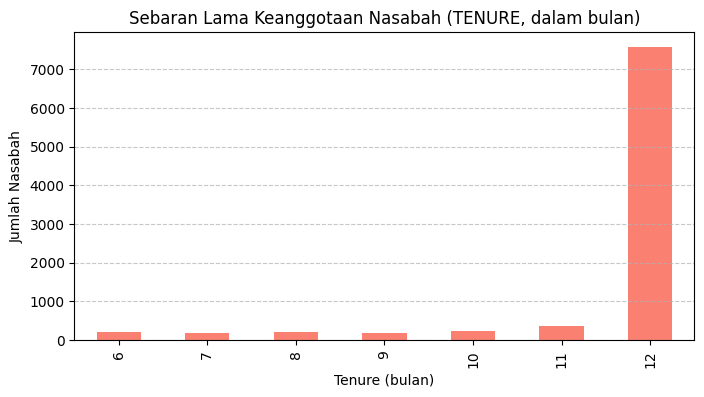

In [11]:
# 2. Distribusi TENURE (lama keanggotaan)
plt.figure(figsize=(8, 4))
df['TENURE'].value_counts().sort_index().plot(kind='bar', color='salmon')
plt.title('Sebaran Lama Keanggotaan Nasabah (TENURE, dalam bulan)')
plt.xlabel('Tenure (bulan)')
plt.ylabel('Jumlah Nasabah')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

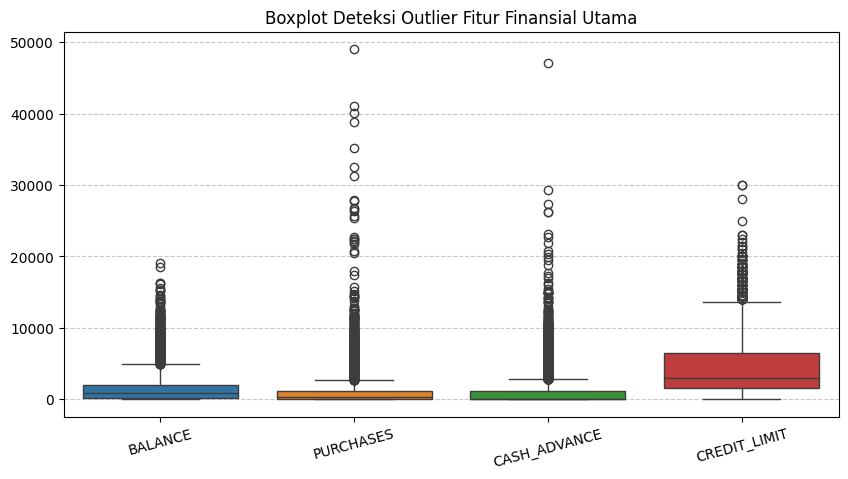

In [12]:
# 3. Boxplot deteksi outlier fitur finansial utama
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']])
plt.title('Boxplot Deteksi Outlier Fitur Finansial Utama')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

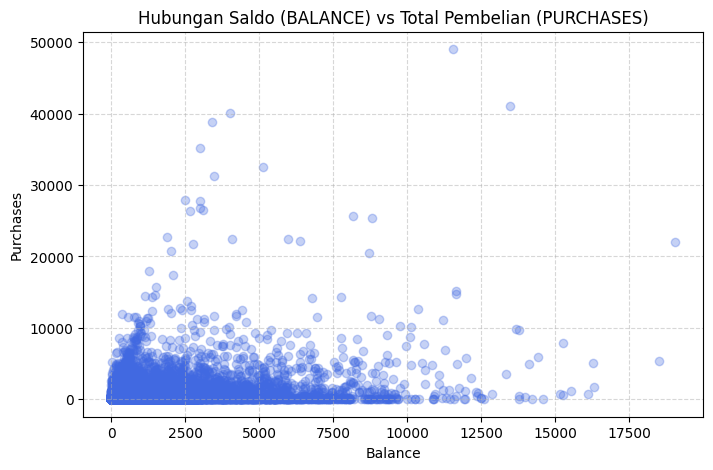

In [13]:
# 4. Scatter plot BALANCE vs PURCHASES
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='royalblue')
plt.title('Hubungan Saldo (BALANCE) vs Total Pembelian (PURCHASES)')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

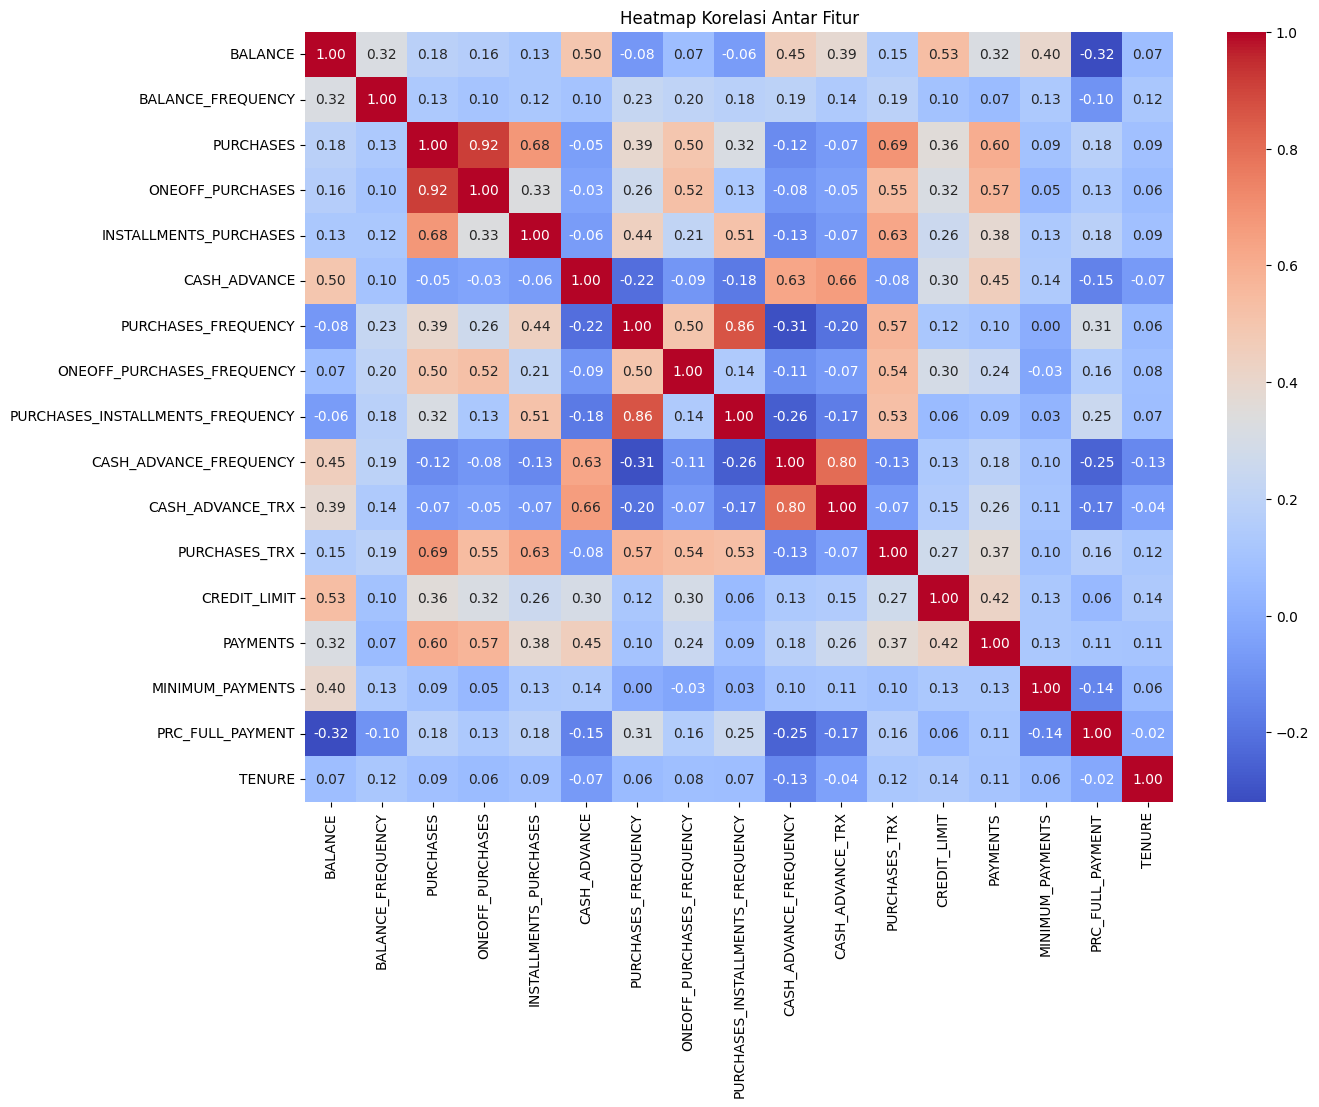

In [14]:
# 5. Heatmap korelasi antar fitur numerik
plt.figure(figsize=(14, 10))
numeric_cols = df.drop(columns=['CUST_ID']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

### 2.5 Kesimpulan Data Understanding

Eksplorasi data mentah (8.950 baris, 18 kolom) memberikan bukti empiris sebagai dasar pembersihan data:
1. **Missing Values:** Ditemukan missing value pada `MINIMUM_PAYMENTS` (313 baris) dan `CREDIT_LIMIT` (1 baris), yang perlu diimputasi agar seluruh baris dapat digunakan pada tahap clustering.
2. **Tidak Ada Data Duplikat:** Pengecekan tidak menemukan baris data yang duplikat, sehingga tidak perlu dilakukan penghapusan baris ganda.
3. **Distribusi Sangat Skewed:** Statistik deskriptif dan visualisasi menunjukkan fitur-fitur finansial utama (`BALANCE`, `PURCHASES`, `CASH_ADVANCE`) memiliki rentang nilai yang sangat lebar (misalnya `PURCHASES` berkisar 0 hingga 49.039, dengan rata-rata hanya 1.003) dan didominasi oleh nilai kecil dengan sebagian kecil nasabah bernilai ekstrem tinggi, sehingga distribusinya menceng (*skewed*) ke kanan dan memerlukan transformasi logaritma sebelum standarisasi.
4. **Perbedaan Skala Antar Fitur:** Rentang nilai antar variabel sangat berbeda (misalnya `BALANCE_FREQUENCY` berskala 0–1, sedangkan `CASH_ADVANCE` bisa mencapai puluhan ribu), sehingga standarisasi fitur menjadi wajib sebelum masuk ke algoritma clustering berbasis jarak seperti K-Means.

## 3. Data Preparation

### 3.1 Penanganan Missing Value dan Seleksi Fitur
Pada tahap ini, kolom `CUST_ID` dibuang karena hanya berfungsi sebagai identitas dan tidak relevan untuk clustering. Missing value pada `CREDIT_LIMIT` dan `MINIMUM_PAYMENTS` diimputasi menggunakan nilai median, karena median lebih tahan terhadap pengaruh outlier dibandingkan mean pada data yang skewed.

In [15]:
# 1. Salin dataframe dan buang kolom identitas
df_prep = df.drop(columns=['CUST_ID']).copy()

# 2. Imputasi missing value dengan median
df_prep['CREDIT_LIMIT'] = df_prep['CREDIT_LIMIT'].fillna(df_prep['CREDIT_LIMIT'].median())
df_prep['MINIMUM_PAYMENTS'] = df_prep['MINIMUM_PAYMENTS'].fillna(df_prep['MINIMUM_PAYMENTS'].median())

# Cek hasil penanganan missing value
print("Sisa missing value setelah imputasi:")
print(df_prep.isnull().sum().sum())

Sisa missing value setelah imputasi:
0


### 3.2 Transformasi Logaritma pada Fitur Skewed
Fitur-fitur finansial seperti `BALANCE`, `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, dan `PAYMENTS` memiliki distribusi yang sangat menceng ke kanan akibat sebagian kecil nasabah dengan nilai transaksi ekstrem. Transformasi logaritma (`log1p`, agar nilai 0 tetap dapat diproses) diterapkan untuk membuat distribusinya lebih mendekati normal sebelum standarisasi.

In [16]:
# Daftar fitur finansial yang skewed
skewed_features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                    'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

# Transformasi logaritma (log1p)
for col in skewed_features:
    df_prep[f'{col}_log'] = np.log1p(df_prep[col])

print("Transformasi logaritma selesai pada", len(skewed_features), "fitur.")

Transformasi logaritma selesai pada 8 fitur.


### 3.3 Standarisasi Fitur
Seluruh fitur yang akan digunakan untuk clustering (hasil transformasi log serta fitur frekuensi/rasio yang sudah berskala 0–1) distandarisasi menggunakan `StandardScaler` agar perbedaan skala antarvariabel tidak mendominasi perhitungan jarak Euclidean pada algoritma K-Means.

In [17]:
from sklearn.preprocessing import StandardScaler

# Fitur final yang dipakai untuk clustering
features_final = [
    'BALANCE_log', 'BALANCE_FREQUENCY', 'PURCHASES_log', 'ONEOFF_PURCHASES_log',
    'INSTALLMENTS_PURCHASES_log', 'CASH_ADVANCE_log', 'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'CREDIT_LIMIT_log', 'PAYMENTS_log', 'MINIMUM_PAYMENTS_log',
    'PRC_FULL_PAYMENT', 'TENURE'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep[features_final])

print("Jumlah fitur yang digunakan untuk clustering:", len(features_final))
print("Dimensi data setelah standarisasi:", X_scaled.shape)

Jumlah fitur yang digunakan untuk clustering: 17
Dimensi data setelah standarisasi: (8950, 17)


### 3.4 Kesimpulan Data Preparation

Pada tahap Data Preparation, kolom `CUST_ID` dibuang karena tidak relevan untuk clustering, dan missing value pada `CREDIT_LIMIT` (1 baris) serta `MINIMUM_PAYMENTS` (313 baris) diimputasi menggunakan median agar seluruh 8.950 baris tetap dapat digunakan tanpa kehilangan data. Delapan fitur finansial yang skewed ditransformasi menggunakan logaritma untuk mengurangi pengaruh nilai ekstrem, kemudian seluruh 17 fitur yang relevan (kombinasi hasil transformasi log dan fitur frekuensi/rasio) distandarisasi menggunakan `StandardScaler`, sehingga dataset siap digunakan pada tahap pemodelan clustering.

## 4. Modeling

### 4.1 Penentuan Jumlah Cluster Terbaik (K)
Evaluasi nilai K optimal dari kisaran 2 hingga 10 menggunakan Metode Elbow (Inertia/WCSS) dan Silhouette Score.

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
k_range = range(2, 11)

# Perhitungan evaluasi K
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

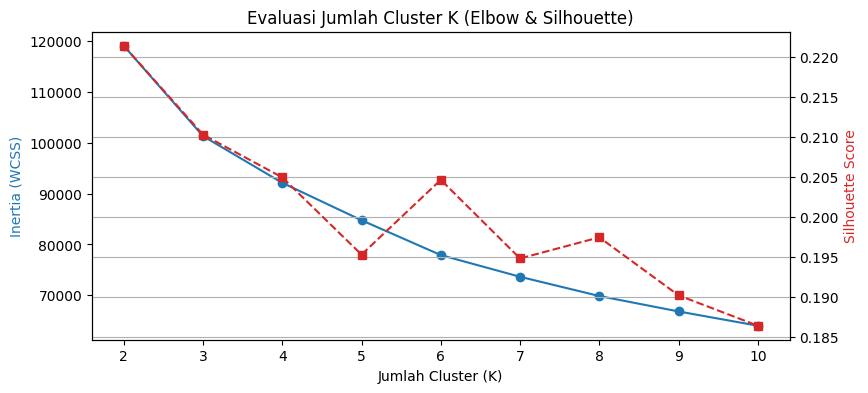

K dengan Silhouette Score tertinggi: 2 -> Score: 0.2214


In [19]:
# Plot Elbow dan Silhouette Score
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia (WCSS)', color='tab:blue')
ax1.plot(k_range, inertia, marker='o', color='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, silhouette_scores, marker='s', color='tab:red', linestyle='--')

plt.title('Evaluasi Jumlah Cluster K (Elbow & Silhouette)')
plt.grid(True)
plt.show()

# Cetak nilai K dengan silhouette terbaik
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print("K dengan Silhouette Score tertinggi:", best_k, "-> Score:", round(max(silhouette_scores), 4))

### 4.2 Penerapan K-Means dan Evaluasi Model Pembanding
Melatih model utama K-Means dengan jumlah cluster (K) yang dipilih berdasarkan titik siku pada grafik Elbow dan nilai Silhouette Score tertinggi, lalu membandingkan performanya dengan algoritma Agglomerative Clustering dan Gaussian Mixture Model (GMM).

In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Tetapkan K final berdasarkan hasil Elbow (titik siku) & Silhouette Score
K_FINAL = 4

# 1. Fit Model Utama: K-Means
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_prep['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Fit Model Pembanding
agg = AgglomerativeClustering(n_clusters=K_FINAL)
cluster_agg = agg.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=K_FINAL, random_state=42)
cluster_gmm = gmm.fit_predict(X_scaled)

# 3. Evaluasi Perbandingan Silhouette Score
print(f"--- Perbandingan Silhouette Score (K={K_FINAL}) ---")
print(f"K-Means (Utama)        : {silhouette_score(X_scaled, df_prep['Cluster']):.4f}")
print(f"Agglomerative          : {silhouette_score(X_scaled, cluster_agg):.4f}")
print(f"Gaussian Mixture (GMM) : {silhouette_score(X_scaled, cluster_gmm):.4f}")

# 4. Profiling singkat hasil cluster K-Means
print("\n--- Ringkasan Rata-Rata Karakteristik Cluster (K-Means) ---")
profile = df_prep.groupby('Cluster')[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']].mean().round(1)
profile['Jumlah Nasabah'] = df_prep['Cluster'].value_counts()
print(profile)

--- Perbandingan Silhouette Score (K=4) ---
K-Means (Utama)        : 0.2050
Agglomerative          : 0.1396
Gaussian Mixture (GMM) : 0.1586

--- Ringkasan Rata-Rata Karakteristik Cluster (K-Means) ---
         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster                                                             
0         2179.6     2839.0         770.2        6580.2    3078.3   
1         2473.8      150.5        2135.1        4396.2    1800.8   
2          644.9      695.2         169.4        3025.7     885.5   
3          113.8      358.3         139.2        3646.7     768.4   

         Jumlah Nasabah  
Cluster                  
0                  2281  
1                  3011  
2                  2194  
3                  1464  


### 4.3 Kesimpulan Modeling

Berdasarkan evaluasi Metode Elbow dan Silhouette Score, dipilih K=4 sebagai jumlah cluster optimal karena berada tepat pada titik siku kurva Inertia dengan Silhouette Score yang masih kompetitif (0,2050). Perbandingan dengan algoritma lain pada K yang sama menunjukkan K-Means unggul dibanding Agglomerative Clustering (0,1396) dan Gaussian Mixture Model (0,1586), sehingga K-Means dipilih sebagai model utama. Profiling awal menunjukkan empat cluster dengan karakteristik yang cukup berbeda: cluster dengan saldo & pembelian tinggi, cluster dengan ketergantungan cash advance tinggi, cluster dengan aktivitas standar, dan cluster dengan aktivitas paling pasif — mengindikasikan pemisahan segmen yang secara bisnis masuk akal.

## 5. Evaluation

### 5.1 Evaluasi Metrik Tambahan
Selain Silhouette Score, kualitas pemisahan cluster diukur juga menggunakan Davies-Bouldin Index dan Calinski-Harabasz Score untuk memastikan hasil clustering K-Means (K=4) benar-benar solid.

In [23]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(X_scaled, df_prep['Cluster'])
db_score = davies_bouldin_score(X_scaled, df_prep['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df_prep['Cluster'])

print("=== METRIK EVALUASI K-MEANS (K=4) ===")
print(f"Silhouette Score       : {sil_score:.4f}  (Mendekati 1 = Pemisahan Sangat Baik)")
print(f"Davies-Bouldin Index   : {db_score:.4f}   (Mendekati 0 = Cluster Semakin Padat)")
print(f"Calinski-Harabasz Score: {ch_score:.2f}   (Makin Tinggi = Kualitas Cluster Lebih Baik)")

=== METRIK EVALUASI K-MEANS (K=4) ===
Silhouette Score       : 0.2050  (Mendekati 1 = Pemisahan Sangat Baik)
Davies-Bouldin Index   : 1.7052   (Mendekati 0 = Cluster Semakin Padat)
Calinski-Harabasz Score: 1942.65   (Makin Tinggi = Kualitas Cluster Lebih Baik)


### 5.2 Penamaan Segmen dan Profiling Bisnis
Berdasarkan karakteristik rata-rata tiap cluster, dilakukan penamaan segmen agar mudah diinterpretasikan dari sudut pandang bisnis.

In [24]:
# Penamaan segmen berdasarkan karakteristik cluster
cluster_labels = {
    0: 'High-Value Spender',
    1: 'Cash Advance Dependent (Berisiko)',
    2: 'Standard User',
    3: 'Nasabah Pasif / Dormant'
}
df_prep['Segmen'] = df_prep['Cluster'].map(cluster_labels)

# Tabel profiling detail per segmen
profile_table = df_prep.groupby(['Cluster', 'Segmen']).agg({
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CASH_ADVANCE': 'mean',
    'CREDIT_LIMIT': 'mean',
    'PAYMENTS': 'mean',
    'TENURE': 'mean'
}).round(1)
profile_table['Jumlah Nasabah'] = df_prep['Cluster'].value_counts()

print("=== RINGKASAN PROFIL TIAP SEGMEN NASABAH ===")
print(profile_table)

=== RINGKASAN PROFIL TIAP SEGMEN NASABAH ===
                                           BALANCE  PURCHASES  CASH_ADVANCE  \
Cluster Segmen                                                                
0       High-Value Spender                  2179.6     2839.0         770.2   
1       Cash Advance Dependent (Berisiko)   2473.8      150.5        2135.1   
2       Standard User                        644.9      695.2         169.4   
3       Nasabah Pasif / Dormant              113.8      358.3         139.2   

                                           CREDIT_LIMIT  PAYMENTS  TENURE  \
Cluster Segmen                                                              
0       High-Value Spender                       6580.2    3078.3    11.8   
1       Cash Advance Dependent (Berisiko)        4396.2    1800.8    11.4   
2       Standard User                            3025.7     885.5    11.5   
3       Nasabah Pasif / Dormant                  3646.7     768.4    11.3   

                 

### 5.3 Visualisasi Sebaran Cluster


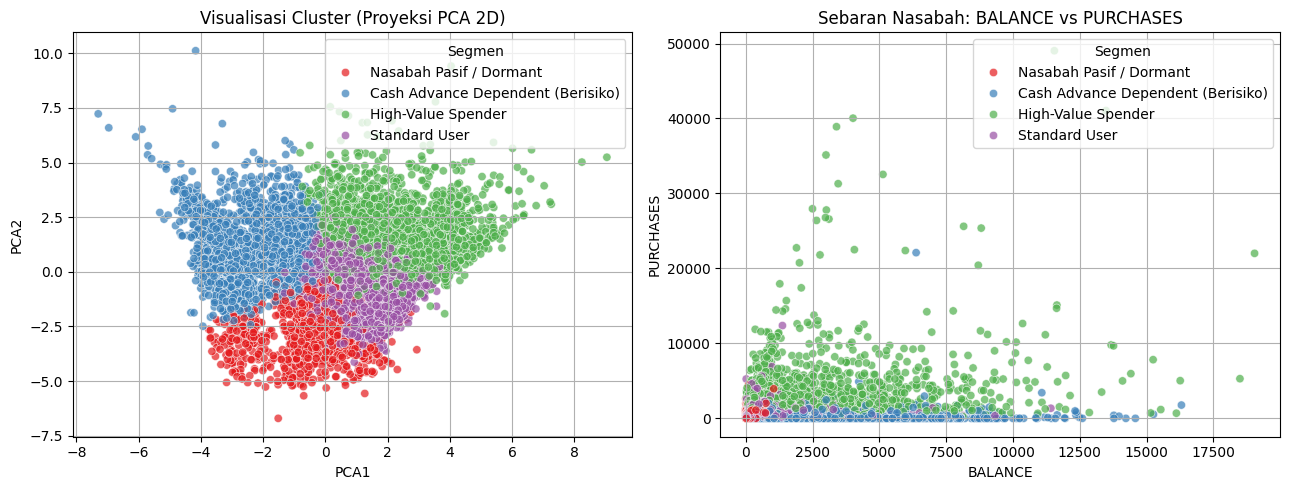

In [25]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df_prep['PCA1'] = pca_coords[:, 0]
df_prep['PCA2'] = pca_coords[:, 1]

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_prep, x='PCA1', y='PCA2', hue='Segmen', palette='Set1', alpha=0.7)
plt.title('Visualisasi Cluster (Proyeksi PCA 2D)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_prep, x='BALANCE', y='PURCHASES', hue='Segmen', palette='Set1', alpha=0.7)
plt.title('Sebaran Nasabah: BALANCE vs PURCHASES')
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.4 Kesimpulan Evaluation

Evaluasi kuantitatif menunjukkan model K-Means (K=4) memiliki Silhouette Score sebesar 0,2050, yang mengindikasikan pemisahan cluster bersifat moderat — cluster dapat dibedakan namun sebagian nasabah berada di batas antar-segmen. Davies-Bouldin Index sebesar 1,7052 relatif tinggi, menandakan ada tumpang tindih antar beberapa cluster, sementara Calinski-Harabasz Score sebesar 1.942,65 menunjukkan variansi antar-cluster masih jauh lebih besar dibanding variansi di dalam cluster. Karakteristik ini wajar mengingat data perilaku finansial nasabah bersifat kontinu dan bertransisi secara halus, bukan terklaster secara alami dengan batas yang tegas. Meski demikian, hasil profiling menunjukkan empat segmen dengan karakteristik bisnis yang berbeda dan dapat diinterpretasikan secara jelas:
1. **High-Value Spender (2.281 nasabah):** saldo dan pembelian tinggi, limit kredit tertinggi (rata-rata 6.580) — nasabah aktif berbelanja dengan nilai besar.
2. **Cash Advance Dependent / Berisiko (3.011 nasabah):** pembelian rendah namun cash advance tertinggi (rata-rata 2.135) — mengindikasikan ketergantungan pada penarikan tunai, berpotensi berisiko dari sisi kredit.
3. **Standard User (2.194 nasabah):** seluruh metrik berada di level moderat-rendah — nasabah dengan aktivitas standar.
4. **Nasabah Pasif / Dormant (1.464 nasabah):** saldo dan pembelian paling rendah (113,8 dan 358,3) — nasabah dengan aktivitas paling minim.

In [26]:
## 6. Deployment

### 6.1 Export Model Artifacts dan Fungsi Prediksi Data Baru
Menyimpan model K-Means, StandardScaler, serta dataset hasil klustering ke dalam format file `.pkl` dan `.csv`. Dibuat pula fungsi inferensi untuk memprediksi segmen nasabah dari masukan data kartu kredit baru secara otomatis.

In [27]:
import joblib

# 1. Simpan dataset hasil klustering ke CSV
df_prep.to_csv('/content/cc_customer_clusters_processed.csv', index=False)

# 2. Simpan objek model K-Means dan StandardScaler
joblib.dump(kmeans_final, '/content/kmeans_cc_model.pkl')
joblib.dump(scaler, '/content/scaler_cc_model.pkl')

print("Artifacts berhasil disimpan!")

# 3. Fungsi Inferensi Prediksi Segmen Nasabah Baru
def prediksi_segmen_nasabah(balance, balance_frequency, purchases, oneoff_purchases,
                              installments_purchases, cash_advance, purchases_frequency,
                              oneoff_purchases_frequency, purchases_installments_frequency,
                              cash_advance_frequency, cash_advance_trx, purchases_trx,
                              credit_limit, payments, minimum_payments,
                              prc_full_payment, tenure):
    # Load model dan scaler
    model = joblib.load('kmeans_cc_model.pkl')
    sc = joblib.load('scaler_cc_model.pkl')

    labels = {
        0: 'High-Value Spender',
        1: 'Cash Advance Dependent (Berisiko)',
        2: 'Standard User',
        3: 'Nasabah Pasif / Dormant'
    }

    # Transformasi logaritma untuk fitur skewed (samakan dengan tahap Data Preparation)
    balance_log = np.log1p(balance)
    purchases_log = np.log1p(purchases)
    oneoff_purchases_log = np.log1p(oneoff_purchases)
    installments_purchases_log = np.log1p(installments_purchases)
    cash_advance_log = np.log1p(cash_advance)
    credit_limit_log = np.log1p(credit_limit)
    payments_log = np.log1p(payments)
    minimum_payments_log = np.log1p(minimum_payments)

    input_data = np.array([[
        balance_log, balance_frequency, purchases_log, oneoff_purchases_log,
        installments_purchases_log, cash_advance_log, purchases_frequency,
        oneoff_purchases_frequency, purchases_installments_frequency,
        cash_advance_frequency, cash_advance_trx, purchases_trx,
        credit_limit_log, payments_log, minimum_payments_log,
        prc_full_payment, tenure
    ]])
    input_scaled = sc.transform(input_data)

    cluster_pred = model.predict(input_scaled)[0]
    return labels[cluster_pred]


# Contoh pengujian data nasabah baru
hasil_prediksi = prediksi_segmen_nasabah(
    balance=1500, balance_frequency=0.9, purchases=800, oneoff_purchases=400,
    installments_purchases=400, cash_advance=0, purchases_frequency=0.8,
    oneoff_purchases_frequency=0.3, purchases_installments_frequency=0.5,
    cash_advance_frequency=0, cash_advance_trx=0, purchases_trx=15,
    credit_limit=5000, payments=1200, minimum_payments=300,
    prc_full_payment=0.2, tenure=12
)
print("\nHasil Prediksi Nasabah Baru:", hasil_prediksi)

Artifacts berhasil disimpan!

Hasil Prediksi Nasabah Baru: High-Value Spender


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
